In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv('../data/processed/nav_history_cleaned.csv')

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='object')

In [3]:
nav['date'] = pd.to_datetime(nav['date'])

In [4]:
nav = nav.sort_values(['amfi_code', 'date'])

In [5]:
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav[['amfi_code', 'date', 'nav', 'daily_return']].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


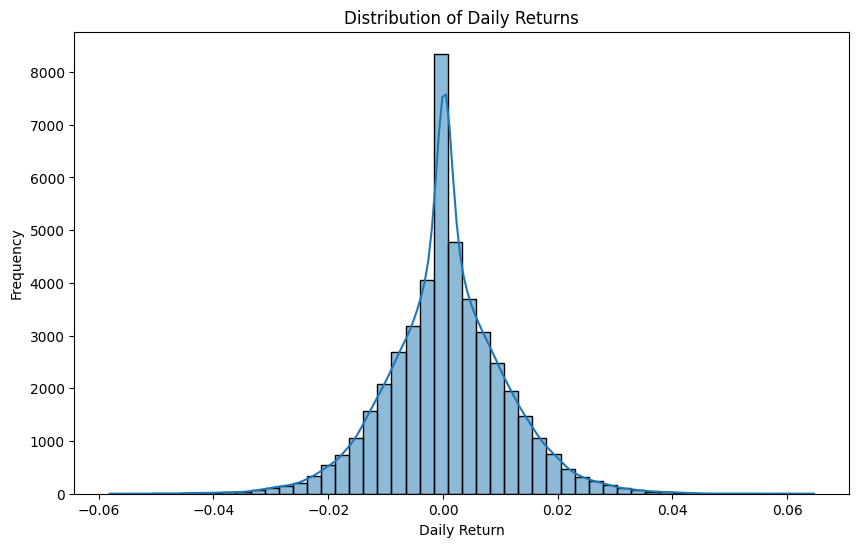

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.show()

Daily returns are concentrated around zero with relatively few extreme movements, indicating stable mutual fund performance.

In [7]:
cagr_list = []

for fund in nav['amfi_code'].unique():

    temp = nav[nav['amfi_code'] == fund]

    temp = temp.sort_values('date')

    nav_start = temp.iloc[0]['nav']
    nav_end = temp.iloc[-1]['nav']

    years = (temp['date'].max() - temp['date'].min()).days / 365

    cagr = ((nav_end / nav_start) ** (1 / years) - 1) * 100

    cagr_list.append({
        'amfi_code': fund,
        'CAGR_pct': cagr
    })

cagr_df = pd.DataFrame(cagr_list)

cagr_df.head()

,amfi_code,CAGR_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [8]:
# Risk-free rate (RBI repo proxy)
rf = 0.065

sharpe_list = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code]

    mean_return = fund['daily_return'].mean() * 252
    std_return = fund['daily_return'].std() * np.sqrt(252)

    if std_return != 0:
        sharpe = (mean_return - rf) / std_return
    else:
        sharpe = np.nan

    sharpe_list.append({
        'amfi_code': code,
        'Sharpe_Ratio': sharpe
    })

sharpe_df = pd.DataFrame(sharpe_list)

sharpe_df = sharpe_df.sort_values(
    by='Sharpe_Ratio',
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


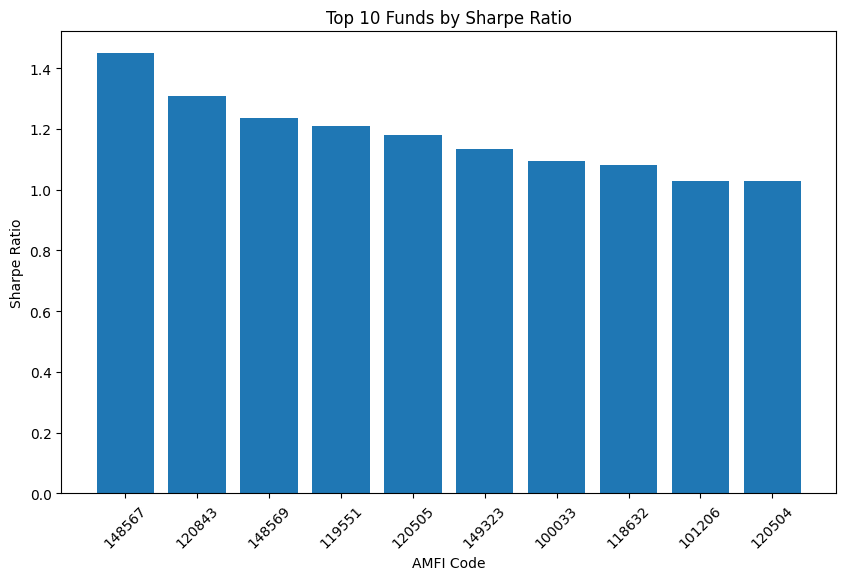

In [9]:
top10_sharpe = sharpe_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_sharpe['amfi_code'].astype(str),
    top10_sharpe['Sharpe_Ratio']
)

plt.title('Top 10 Funds by Sharpe Ratio')
plt.xlabel('AMFI Code')
plt.ylabel('Sharpe Ratio')
plt.xticks(rotation=45)

plt.show()

In [10]:
sortino_list = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code]

    mean_return = fund['daily_return'].mean() * 252

    downside_returns = fund['daily_return'][fund['daily_return'] < 0]

    downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std != 0 and not np.isnan(downside_std):
        sortino = (mean_return - rf) / downside_std
    else:
        sortino = np.nan

    sortino_list.append({
        'amfi_code': code,
        'Sortino_Ratio': sortino
    })

sortino_df = pd.DataFrame(sortino_list)

sortino_df = sortino_df.sort_values(
    by='Sortino_Ratio',
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


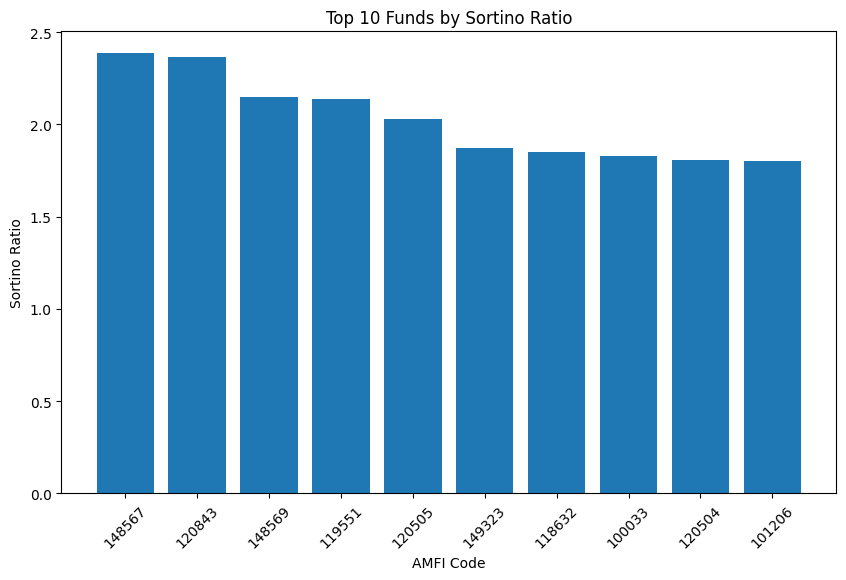

In [11]:
top10_sortino = sortino_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_sortino['amfi_code'].astype(str),
    top10_sortino['Sortino_Ratio']
)

plt.title('Top 10 Funds by Sortino Ratio')
plt.xlabel('AMFI Code')
plt.ylabel('Sortino Ratio')
plt.xticks(rotation=45)

plt.show()

In [12]:
import os

os.listdir('../data/raw')

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'HDFC_Top_100_Direct.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [13]:
benchmark = pd.read_csv('../data/raw/10_benchmark_indices.csv')

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [14]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [15]:
# Keep only NIFTY50 data
nifty50 = benchmark[benchmark['index_name'] == 'NIFTY50'].copy()

# Convert date column to datetime
nifty50['date'] = pd.to_datetime(nifty50['date'])

# Sort by date
nifty50 = nifty50.sort_values('date')

# Calculate daily benchmark returns
nifty50['benchmark_return'] = nifty50['close_value'].pct_change()

nifty50.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [16]:
from scipy.stats import linregress

alpha_beta_list = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code].copy()

    # Merge fund returns with benchmark returns
    merged = pd.merge(
        fund[['date', 'daily_return']],
        nifty50[['date', 'benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) > 30:   # Minimum observations

        slope, intercept, r_value, p_value, std_err = linregress(
            merged['benchmark_return'],
            merged['daily_return']
        )

        beta = slope
        alpha = intercept * 252 * 100

        alpha_beta_list.append({
            'amfi_code': code,
            'Alpha_pct': alpha,
            'Beta': beta
        })

alpha_beta_df = pd.DataFrame(alpha_beta_list)

alpha_beta_df = alpha_beta_df.sort_values(
    by='Alpha_pct',
    ascending=False
)

alpha_beta_df.head(10)

,amfi_code,Alpha_pct,Beta
21,119598,30.111442,0.074266
39,149324,29.817869,0.132608
25,120505,29.301371,-0.017391
36,148569,28.347336,-0.010201
30,120843,27.278360,-0.008737
2,100033,27.234304,-0.011200
34,148567,27.115016,-0.028133
38,149323,26.583594,0.003479
16,119094,25.997054,-0.059868
19,119551,23.219648,-0.056045


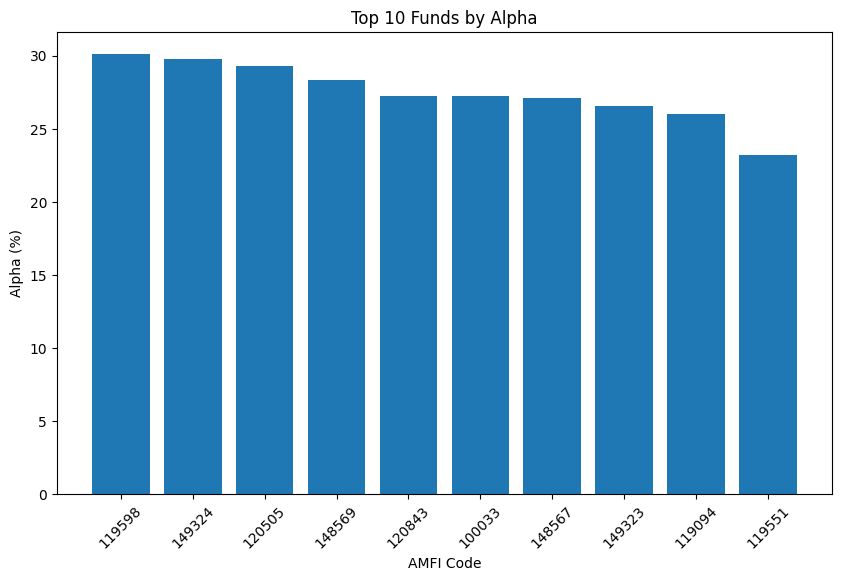

In [17]:
top10_alpha = alpha_beta_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10_alpha['amfi_code'].astype(str),
    top10_alpha['Alpha_pct']
)

plt.title('Top 10 Funds by Alpha')
plt.xlabel('AMFI Code')
plt.ylabel('Alpha (%)')
plt.xticks(rotation=45)

plt.show()

Insight 4:

Funds with higher positive Alpha values outperform the benchmark index, indicating superior fund management and stock selection skills.

Insight 5:

Most funds exhibit low Beta values, suggesting lower sensitivity to overall market movements.

In [18]:
max_dd_list = []

for code in nav['amfi_code'].unique():

    fund = nav[nav['amfi_code'] == code].copy()

    fund = fund.sort_values('date')

    # Running maximum NAV
    fund['running_max'] = fund['nav'].cummax()

    # Drawdown
    fund['drawdown'] = (fund['nav'] /
                        fund['running_max']) - 1

    max_dd = fund['drawdown'].min()

    max_dd_list.append({
        'amfi_code': code,
        'Max_Drawdown_pct': max_dd * 100
    })

max_dd_df = pd.DataFrame(max_dd_list)

# Worst drawdowns first
max_dd_df = max_dd_df.sort_values(
    by='Max_Drawdown_pct'
)

max_dd_df.head(10)

,amfi_code,Max_Drawdown_pct
22,119599,-52.574221
17,119095,-51.677754
4,101207,-35.446916
39,149324,-31.171900
21,119598,-28.706006
7,102886,-28.001124
0,100016,-24.734441
29,120842,-24.003511
11,118634,-23.344886
15,119093,-21.751396


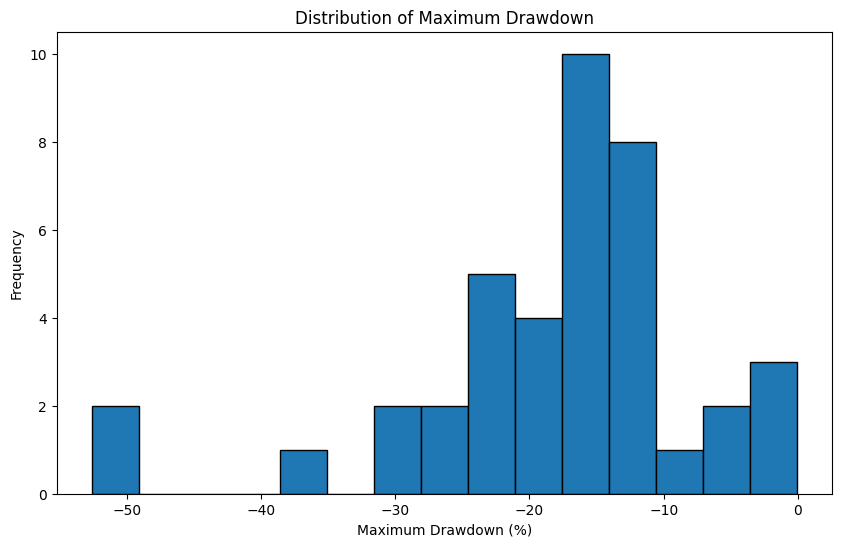

In [19]:
plt.figure(figsize=(10,6))

plt.hist(
    max_dd_df['Max_Drawdown_pct'],
    bins=15,
    edgecolor='black'
)

plt.title('Distribution of Maximum Drawdown')
plt.xlabel('Maximum Drawdown (%)')
plt.ylabel('Frequency')

plt.show()

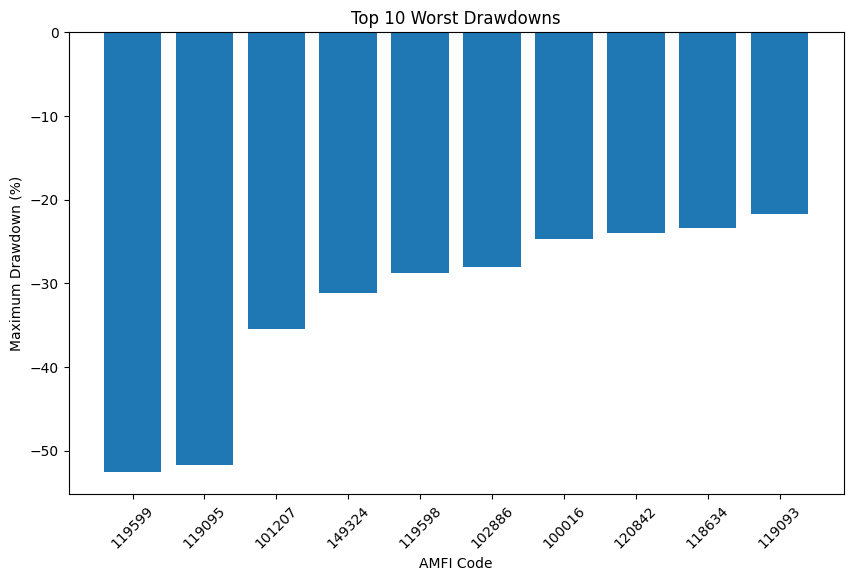

In [20]:
worst_dd = max_dd_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    worst_dd['amfi_code'].astype(str),
    worst_dd['Max_Drawdown_pct']
)

plt.title('Top 10 Worst Drawdowns')
plt.xlabel('AMFI Code')
plt.ylabel('Maximum Drawdown (%)')
plt.xticks(rotation=45)

plt.show()

Insight 6:

Certain funds experienced severe drawdowns exceeding 50%, indicating significant downside risk during adverse market conditions.

Insight 7:

Most mutual funds recorded maximum drawdowns between -10% and -25%, suggesting moderate resilience during market downturns.

Insight 8:

Funds with lower maximum drawdowns are generally more suitable for risk-averse investors seeking capital preservation.

In [21]:
# Merge all performance metrics

scorecard = cagr_df.merge(sharpe_df, on='amfi_code')
scorecard = scorecard.merge(alpha_beta_df[['amfi_code', 'Alpha_pct']],
                            on='amfi_code')
scorecard = scorecard.merge(max_dd_df,
                            on='amfi_code')

In [22]:
scheme_perf = pd.read_csv('../data/raw/07_scheme_performance.csv')

scheme_perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [23]:
scheme_perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')

In [24]:
scorecard = scorecard.merge(
    scheme_perf[['amfi_code', 'expense_ratio_pct']],
    on='amfi_code',
    how='left'
)

scorecard.head()

,amfi_code,CAGR_pct,Sharpe_Ratio,Alpha_pct,Max_Drawdown_pct,expense_ratio_pct
0,100016,2.635246,-0.201517,3.622083,-24.734441,1.55
1,100025,4.455091,-0.567095,4.318931,-4.308264,0.56
2,100033,30.099704,1.093699,27.234304,-16.217209,1.38
3,101206,23.520489,1.027213,21.394475,-11.291596,1.60
4,101207,7.933121,0.162661,10.820455,-35.446916,1.53


In [25]:
# Higher is better
scorecard['CAGR_rank'] = scorecard['CAGR_pct'].rank(ascending=False)
scorecard['Sharpe_rank'] = scorecard['Sharpe_Ratio'].rank(ascending=False)
scorecard['Alpha_rank'] = scorecard['Alpha_pct'].rank(ascending=False)

# Lower is better
scorecard['Expense_rank'] = scorecard['expense_ratio_pct'].rank(ascending=True)
scorecard['DD_rank'] = scorecard['Max_Drawdown_pct'].rank(ascending=False)

In [26]:
scorecard['Fund_Score'] = (
    0.30 * scorecard['CAGR_rank'] +
    0.25 * scorecard['Sharpe_rank'] +
    0.20 * scorecard['Alpha_rank'] +
    0.15 * scorecard['Expense_rank'] +
    0.10 * scorecard['DD_rank']
)

In [27]:
max_score = scorecard['Fund_Score'].max()
min_score = scorecard['Fund_Score'].min()

scorecard['Fund_Score_100'] = (
    (max_score - scorecard['Fund_Score']) /
    (max_score - min_score)
) * 100

In [28]:
scorecard = scorecard.sort_values(
    'Fund_Score_100',
    ascending=False
)

scorecard[['amfi_code',
            'Fund_Score_100']].head(10)

,amfi_code,Fund_Score_100
25,120505,100.000000
34,148567,98.292058
30,120843,96.584116
2,100033,90.777114
36,148569,88.300598
21,119598,85.824082
24,120504,82.578992
20,119552,81.895816
39,149324,81.810418
19,119551,81.639624


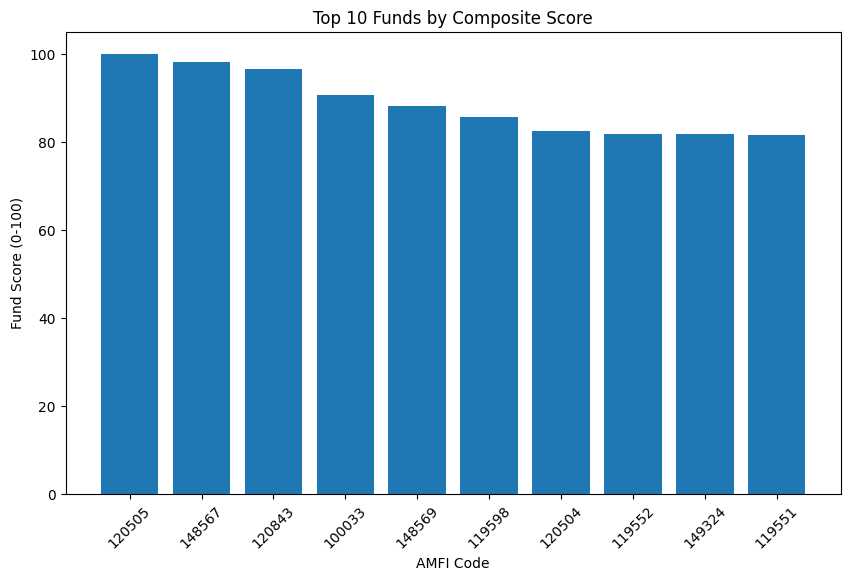

In [29]:
top10 = scorecard.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10['amfi_code'].astype(str),
    top10['Fund_Score_100']
)

plt.title('Top 10 Funds by Composite Score')
plt.xlabel('AMFI Code')
plt.ylabel('Fund Score (0-100)')
plt.xticks(rotation=45)

plt.show()

In [30]:
scorecard.to_csv(
    '../reports/fund_scorecard.csv',
    index=False
)

In [31]:
alpha_beta_df.to_csv(
    '../reports/alpha_beta.csv',
    index=False
)

In [32]:
top5_funds = scorecard.head(5)['amfi_code'].tolist()

print(top5_funds)

[120505, 148567, 120843, 100033, 148569]


In [33]:
top5_nav = nav[nav['amfi_code'].isin(top5_funds)]

top5_nav.head()

,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [34]:
top5_nav['date'] = pd.to_datetime(top5_nav['date'])

top5_nav.head()

C:\Users\Venu Keerthana\AppData\Local\Temp\ipykernel_11056\520847307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5_nav['date'] = pd.to_datetime(top5_nav['date'])


,amfi_code,date,nav,daily_return
2300,100033,2022-01-03,107.3758,NaN
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748


In [35]:
latest_date = top5_nav['date'].max()

start_date = latest_date - pd.DateOffset(years=3)

top5_nav = top5_nav[top5_nav['date'] >= start_date]

print(top5_nav.shape)

(3925, 4)


In [36]:
comparison_df = pd.DataFrame()

for code in top5_funds:

    temp = top5_nav[top5_nav['amfi_code'] == code].copy()

    temp = temp.sort_values('date')

    temp['normalized_nav'] = (
        temp['nav'] / temp['nav'].iloc[0]
    ) * 100

    comparison_df[str(code)] = temp['normalized_nav'].values

In [37]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

benchmark = benchmark[
    benchmark['date'] >= start_date
]

In [38]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [39]:
nifty50 = nifty50.sort_values('date')
nifty100 = nifty100.sort_values('date')

nifty50['normalized'] = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
) * 100

nifty100['normalized'] = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

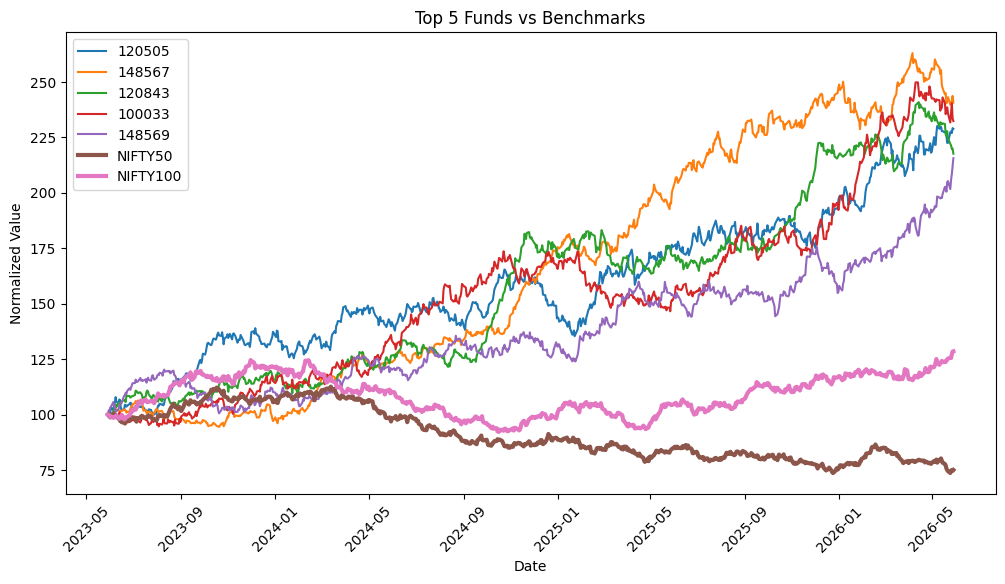

<Figure size 640x480 with 0 Axes>

In [43]:
plt.figure(figsize=(12,6))

for code in top5_funds:

    temp = top5_nav[
        top5_nav['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        (temp['nav']/temp['nav'].iloc[0])*100,
        label=str(code)
    )

plt.plot(
    nifty50['date'],
    nifty50['normalized'],
    label='NIFTY50',
    linewidth=3
)

plt.plot(
    nifty100['date'],
    nifty100['normalized'],
    label='NIFTY100',
    linewidth=3
)

plt.title('Top 5 Funds vs Benchmarks')

plt.xlabel('Date')

plt.ylabel('Normalized Value')

plt.legend()

plt.xticks(rotation=45)

plt.show()

plt.savefig('../reports/benchmark_comparison.png')

In [41]:
plt.savefig('../reports/benchmark_comparison.png')

<Figure size 640x480 with 0 Axes>

C:\Users\Venu Keerthana\AppData\Local\Temp\ipykernel_11056\2927032408.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


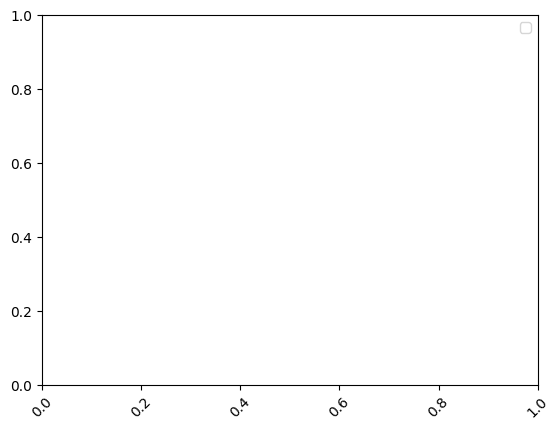

In [42]:
plt.legend()

plt.xticks(rotation=45)

plt.savefig('../reports/benchmark_comparison.png')

plt.show()